In [1]:
pip install mne

## 1. Import thư viện

In [2]:
import mne
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

## 2. Tải data lên

In [3]:
raw_fname = "/content/drive/MyDrive/mne_data/MNE-brainstorm-data/bst_raw/MEG/bst_raw/subj001_somatosensory_20111109_01_AUX-f.ds"
raw = mne.io.read_raw_ctf(raw_fname, preload=True)
raw.pick_types(eeg=True, meg=False).pick_channels(['EEG057'])

ds directory : /content/drive/MyDrive/mne_data/MNE-brainstorm-data/bst_raw/MEG/bst_raw/subj001_somatosensory_20111109_01_AUX-f.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
       0.84   69.49    0.00 mm <->    0.84   69.49   -0.00 mm (orig :  -44.30   51.45 -252.43 mm) diff =    0.000 mm
      -0.84  -69.49    0.00 mm <->   -0.84  -69.49    0.00 mm (orig :   46.28  -53.58 -243.47 mm) diff =    0.000 mm
      86.41    0.00    0.00 mm <->   86.41    0.00    0.00 mm (orig :   63.60   55.82 -230.26 mm) diff =    0.000 mm
    Coordinate transformations established.
    Reading digitizer points from ['/content/drive/MyDrive/mne_data/MNE-brainstorm-data/bst_raw/MEG/bst_raw/subj001_somatosensory_20111109_01_AUX-f.ds/subj00111092011.pos']...
    Polhemus data for 3 HPI coils added
    Device coordinate locations for 3 HPI coils added
Picked positions of 2 EEG channels from channel info
    2 EEG loca

<RawCTF | subj001_somatosensory_20111109_01_AUX-f.meg4, 1 x 432000 (360.0 s), ~3.4 MiB, data loaded>

## 3. Plot đầu tiên

Using matplotlib as 2D backend.


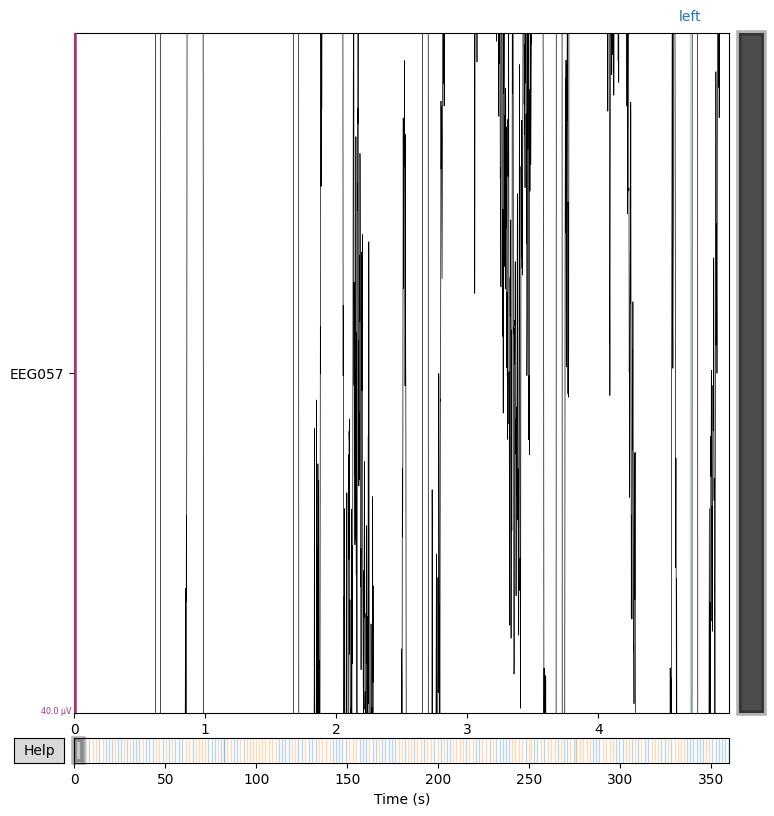

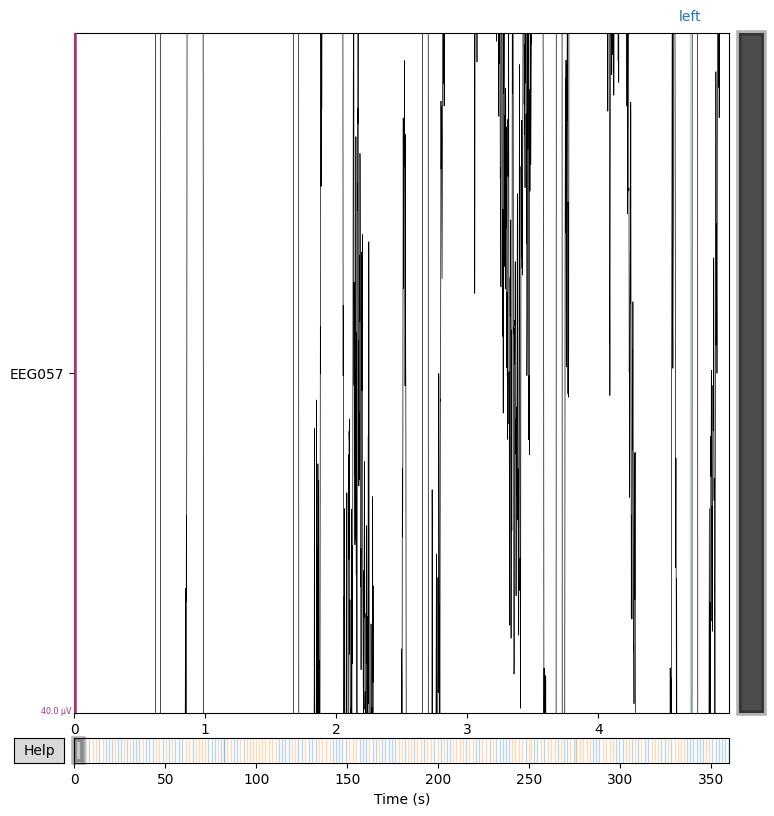

In [4]:
raw.plot(duration=5)

## 4. Lọc dữ liệu và EDA


- Lọc dữ liệu

In [5]:
raw_eeg = raw.copy().pick_types(eeg=True, meg=False)

raw_band = raw_eeg.copy().filter(
    l_freq=1,
    h_freq=40,
    method='fir',
    phase='zero'
)
raw_clean = raw_band.copy().notch_filter(
    freqs=50,
    method='fir'
)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3961 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transiti

- Plot sau khi lọc

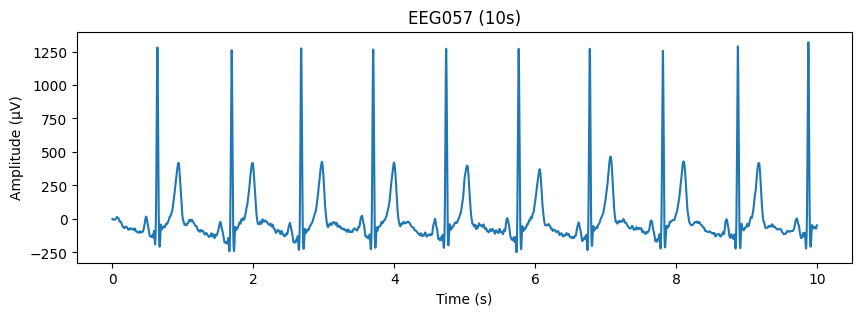

In [6]:
sfreq = raw_clean.info["sfreq"]

duration_sec = 10

start = 0
end = int(duration_sec * sfreq)

times = raw_clean.times[start:end]

for ch in raw_clean.ch_names:
    data = raw_clean.get_data(picks=[ch])[0, start:end] * 1e6

    plt.figure(figsize=(10,3))
    plt.plot(times, data)
    plt.title(f"{ch} ({duration_sec}s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (µV)")
    plt.show()

- PSD

Effective window size : 1.707 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


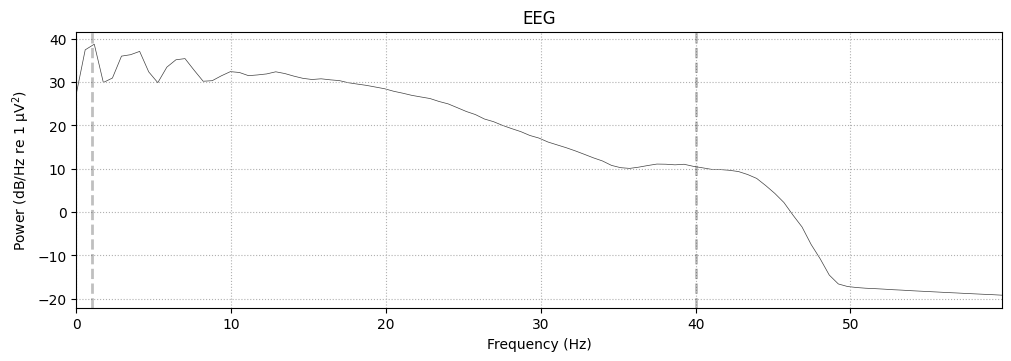

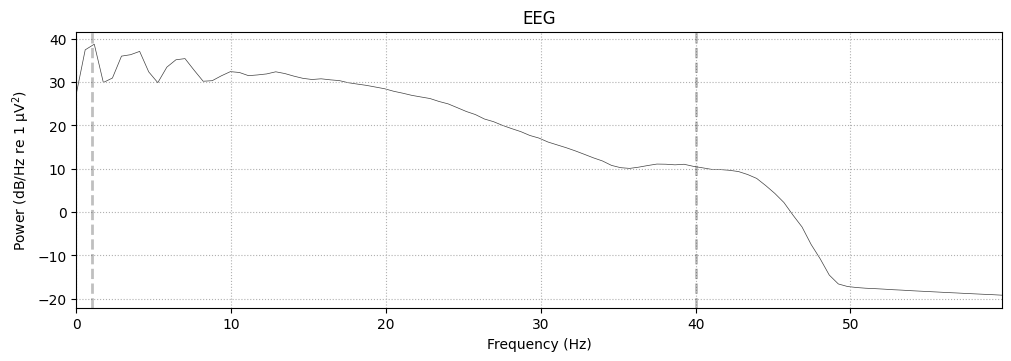

In [7]:
raw_clean.compute_psd(fmax=60).plot()

- Spectrogram

In [8]:
data = raw_clean.get_data()
data = data[0]

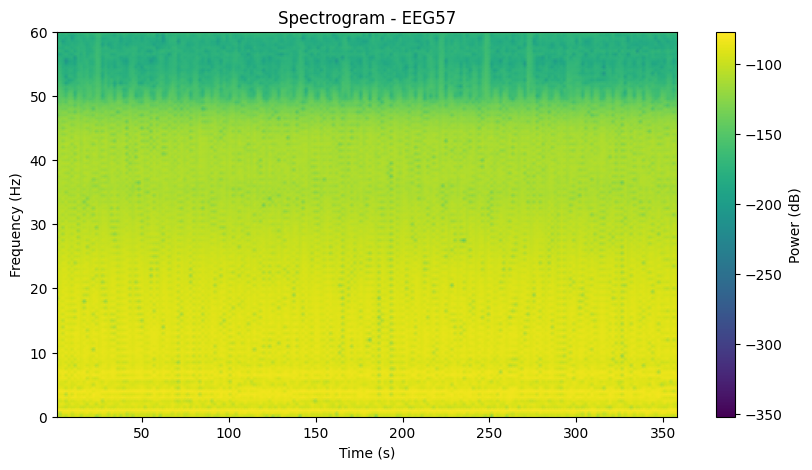

In [9]:
f57, t57, Sxx57 = signal.spectrogram(
    data,
    sfreq,
    nperseg=int(sfreq*2)
)

plt.figure(figsize=(10,5))
plt.pcolormesh(t57, f57, 10*np.log10(Sxx57), shading='gouraud')
plt.title("Spectrogram - EEG57")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.ylim(0, 60)
plt.colorbar(label="Power (dB)")
plt.show()

## 5.Stationarity checks; AR/MA/ARMA

- ADF

In [10]:
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC", maxlag=50)
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

adf_test(data)

Results of Dickey-Fuller Test:
Test Statistic                    -56.775477
p-value                             0.000000
#Lags Used                         50.000000
Number of Observations Used    431949.000000
Critical Value (1%)                -3.430365
Critical Value (5%)                -2.861547
Critical Value (10%)               -2.566774
dtype: float64


- ACF & PACF

In [11]:
#plot_acf(data, lags=range(100,110))
#plt.title("ACF-EEG57")
#plt.show()
#plot_pacf(data, lags=10, method='ywm')
#plt.title("PACF-EEG57")
#plt.show()

- AR

In [12]:
modelAR = AutoReg(data, lags=2)
resultAR = modelAR.fit()

print(resultAR.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:               432000
Model:                     AutoReg(2)   Log Likelihood             5362134.591
Method:               Conditional MLE   S.D. of innovations              0.000
Date:                Wed, 25 Mar 2026   AIC                      -10724261.183
Time:                        14:21:49   BIC                      -10724217.278
Sample:                             2   HQIC                     -10724248.678
                               432000                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       9.081e-11    1.5e-09      0.061      0.952   -2.84e-09    3.03e-09
y.L1           1.9932      0.000   1.57e+04      0.000       1.993       1.993
y.L2          -0.9965      0.000  -7849.076      0.0

- MA

In [13]:
modelMA = ARIMA(data, order=(0, 0, 2))
resultMA = modelMA.fit()

print(resultMA.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:               432000
Model:                 ARIMA(0, 0, 2)   Log Likelihood             3054405.698
Date:                Wed, 25 Mar 2026   AIC                       -6108803.396
Time:                        14:24:02   BIC                       -6108759.491
Sample:                             0   HQIC                      -6108790.891
                             - 432000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        2.67e-08   5.69e-07      0.047      0.963   -1.09e-06    1.14e-06
ma.L1               0   7.13e-13          0      1.000    -1.4e-12     1.4e-12
ma.L2               0   2.63e-12          0      1.0

- ARMA

In [14]:
modelARMA = ARIMA(data, order=(2, 0, 2))
resultARMA = modelARMA.fit()

print(resultARMA.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:               432000
Model:                 ARIMA(2, 0, 2)   Log Likelihood             4574501.928
Date:                Wed, 25 Mar 2026   AIC                       -9148991.856
Time:                        14:28:59   BIC                       -9148925.999
Sample:                             0   HQIC                      -9148973.099
                             - 432000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        2.67e-08   4.51e-05      0.001      1.000   -8.84e-05    8.85e-05
ar.L1          1.9929   6.61e-06   3.01e+05      0.000       1.993       1.993
ar.L2         -0.9962    6.6e-06  -1.51e+05      0.0

###6. Model Selection

In [15]:
best_aic = np.inf
best_order = None

for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(data[:30000], order=(p,0,q)).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_order = (p,0,q)
        except:
            continue

print("Best order:", best_order)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Like

Best order: (3, 0, 0)


###7. Residual

In [16]:
modelsel = AutoReg(data, lags=3)
resultsel = modelsel.fit()
residuals = resultsel.resid

Plot residuals

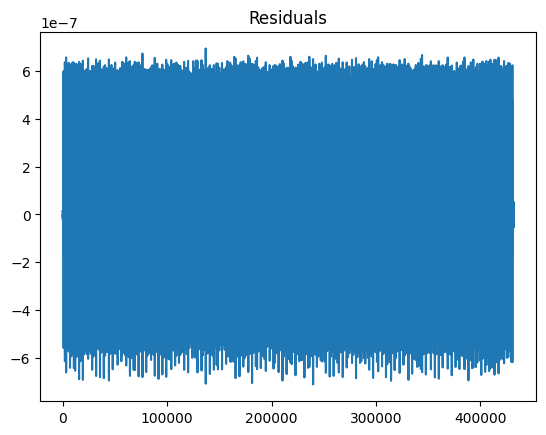

In [17]:
plt.plot(residuals)
plt.title("Residuals")
plt.show()

ACF residuals

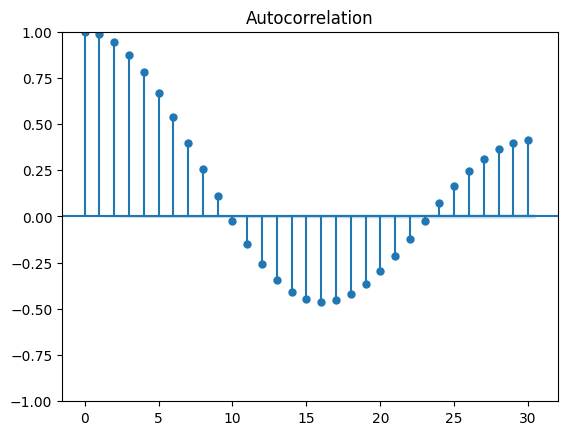

In [18]:
plot_acf(residuals, lags=30)
plt.show()

###8. Forecasting

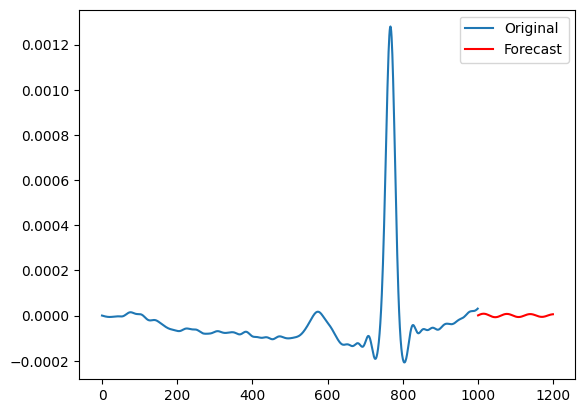

In [22]:
forecast = resultsel.forecast(steps=200)

plt.plot(data[:1000], label="Original")
plt.plot(range(1000, 1200), forecast, label="Forecast", color='red')
plt.legend()
plt.show()